# Merganser Simulatie Resultaten — Analyse
Comparison of damping configurations: `low`, `linhigh`, `quadhigh`, `DOFbest`

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
# ── Paths ───────────────────────────────────────────────────────────────────
INPUT_FILE   = 'Input_Theave.xlsx'
RESULTS_FILE = 'Results_Theave.xlsx'

DIR_PLOTS   = Path('plots')
DIR_RESULTS = Path('results')
DIR_PLOTS.mkdir(exist_ok=True)
DIR_RESULTS.mkdir(exist_ok=True)

# 9 raw columns in the order OrcaFlex writes them:
# grouped per DOF: std/max/mean heave, then pitch, then roll
DOF_COLS_RAW = [
    'heave_std', 'pitch_std', 'roll_std',
    'heave_max', 'pitch_max', 'roll_max',
    'heave_mean',  'pitch_mean',  'roll_mean',
]

# Analysis columns after processing (mean removed, max corrected)
ANALYSIS_COLS = ['heave_std', 'pitch_std', 'roll_std',
                 'heave_max', 'pitch_max', 'roll_max']

DOF_LABELS  = {'heave': 'Heave', 'pitch': 'Pitch', 'roll': 'Roll'}
STAT_LABELS = {'std': 'Std dev', 'max': 'Max (mean-corrected)'}
CONFIGS     = ['low', 'linhigh', 'quadhigh', 'DOFbest']

# ── Direction filters per DOF ───────────────────────────────────────────────
# Roll  : exclude 0° and 180° (symmetric directions)
# Pitch : exclude 90°
# Heave : no exclusion
DIR_EXCLUDE = {
    'heave': [],
    'pitch': [90],
    'roll' : [0, 180],
}

sns.set_theme(style='whitegrid', palette='tab10')

# ── Font sizes ──────────────────────────────────────────────────────────────
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE  = 14
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 — Consistency check: input vs. results

In [24]:
# ── Laad input sweep ───────────────────────────────────────────────────────
# Rij 0 = tekstregel (overgeslagen), rij 1 = kolomnamen
df_input = pd.read_excel(INPUT_FILE, header=1)
df_input.columns = df_input.columns.str.strip('%')
n_input = len(df_input)

# ── Laad resultaten ────────────────────────────────────────────────────────
# Resultaten staan BREED: rij 1 = kolomnamen, rij 2 = waarden
# Elke case heeft 9 kolommen; aantal cases = data-kolommen / 9
raw_res      = pd.read_excel(RESULTS_FILE, header=0)
n_cols_total = raw_res.shape[1]
n_cols_data  = raw_res.dropna(axis=1, how='all').shape[1]
n_res        = n_cols_data // len(DOF_COLS_RAW)

# ── Case-aantal check ──────────────────────────────────────────────────────
print(f'Cases in input sweep            : {n_input}')
print(f'Total columns in results        : {n_cols_total}')
print(f'Columns with data               : {n_cols_data}')
print(f'Derived cases (columns / 9)    : {n_res}')

if n_input == n_res:
    print('\n✅  Counts match — proceeding to analysis.')
else:
    diff = n_res - n_input
    print(f'\n⚠️  MISMATCH: {abs(diff)} case(s) '
          f'{"too many" if diff > 0 else "missing"} in results.')
    if n_cols_total != n_cols_data:
        print(f'   Note: {n_cols_total - n_cols_data} header column(s) without data '
              f'(likely trailing header columns).')
    print('   Check that all simulations completed and the correct file is loaded.')

# ── Structuur-check ────────────────────────────────────────────────────────
if n_cols_data % len(DOF_COLS_RAW) != 0:
    print(f'\n⚠️  {n_cols_data} data columns not divisible by {len(DOF_COLS_RAW)}: '
          f'check that all cases have exactly 9 columns.')
else:
    print(f'✅  Column structure correct ({n_cols_data} = {n_res} × {len(DOF_COLS_RAW)}).')

Cases in input sweep            : 120
Total columns in results        : 1080
Columns with data               : 1080
Derived cases (columns / 9)    : 120

✅  Counts match — proceeding to analysis.
✅  Column structure correct (1080 = 120 × 9).


## 2 — Prepare data

In [25]:
# ── Resultaten: breed → lang ───────────────────────────────────────────────
res_data = raw_res.dropna(axis=1, how='all')
values   = res_data.iloc[0].values
arr      = values.reshape(n_res, len(DOF_COLS_RAW))     # (200, 9)
df_res   = pd.DataFrame(arr, columns=DOF_COLS_RAW)

# ── Correct max for mean offset (removes DC bias from peak) ─────────────────
# max_corr = max - |mean|
for dof in ['heave', 'pitch', 'roll']:
    df_res[f'{dof}_max'] = df_res[f'{dof}_max'] - df_res[f'{dof}_mean']

# ── Drop mean columns (not relevant for analysis) ───────────────────────────
df_res = df_res.drop(columns=['heave_mean', 'pitch_mean', 'roll_mean'])

# ── Merge with input parameters ─────────────────────────────────────────────
df = pd.concat([
    df_input[['Hs', 'Tp', 'Direction', 'Damp_Heave']].reset_index(drop=True),
    df_res.reset_index(drop=True)
], axis=1).rename(columns={'Damp_Heave': 'damp_config'})

df['Hs']        = df['Hs'].astype(float)
df['Tp']        = df['Tp'].astype(float)
df['Direction'] = df['Direction'].astype(int)
df['damp_config'] = pd.Categorical(df['damp_config'], categories=CONFIGS, ordered=True)

# ── Save combined dataframe ──────────────────────────────────────────────────
df.to_csv(DIR_RESULTS / 'resultscombined_Theave.csv', index=False)
print(f'✅ Combined dataframe saved to {DIR_RESULTS}/resultscombined_Theave.csv')

print(df.head(10))
print(f'\nShape: {df.shape}')
print('\nDamping configs:')
print(df['damp_config'].value_counts().sort_index())
print('\nColumns:', df.columns.tolist())

✅ Combined dataframe saved to results/resultscombined_Theave.csv
    Hs    Tp  Direction damp_config  heave_std  pitch_std  roll_std  \
0  1.0  3.58          0         low   0.029089   0.715896  0.000029   
1  1.0  3.58         45         low   0.024757   0.304493  0.424653   
2  1.0  3.58         90         low   0.018734   0.212925  0.307590   
3  1.0  3.58        135         low   0.024892   0.261928  0.160991   
4  1.0  3.58        180         low   0.033307   0.725238  0.000027   
5  1.0  4.08          0         low   0.053931   0.824871  0.000054   
6  1.0  4.08         45         low   0.056787   0.357253  0.532487   
7  1.0  4.08         90         low   0.049742   0.322490  0.335202   
8  1.0  4.08        135         low   0.052838   0.284994  0.177886   
9  1.0  4.08        180         low   0.064879   0.858854  0.000051   

   heave_max  pitch_max  roll_max  
0   0.109490   2.858963  0.000148  
1   0.090020   1.365549  1.786720  
2   0.064760   0.843125  1.333966  
3   0.097

## 3 — Overview: boxplots per damping config
Directions filtered per DOF (roll: excl. 0°/180°; pitch: excl. 90°).

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\160428981.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\verav\AppData\Local\Temp\ipykernel_13508\160428981.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\verav\AppData\Local\Temp\ipykernel_13508\160428981.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\verav\AppData\Local\Temp\ipykernel_13508\160428981.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

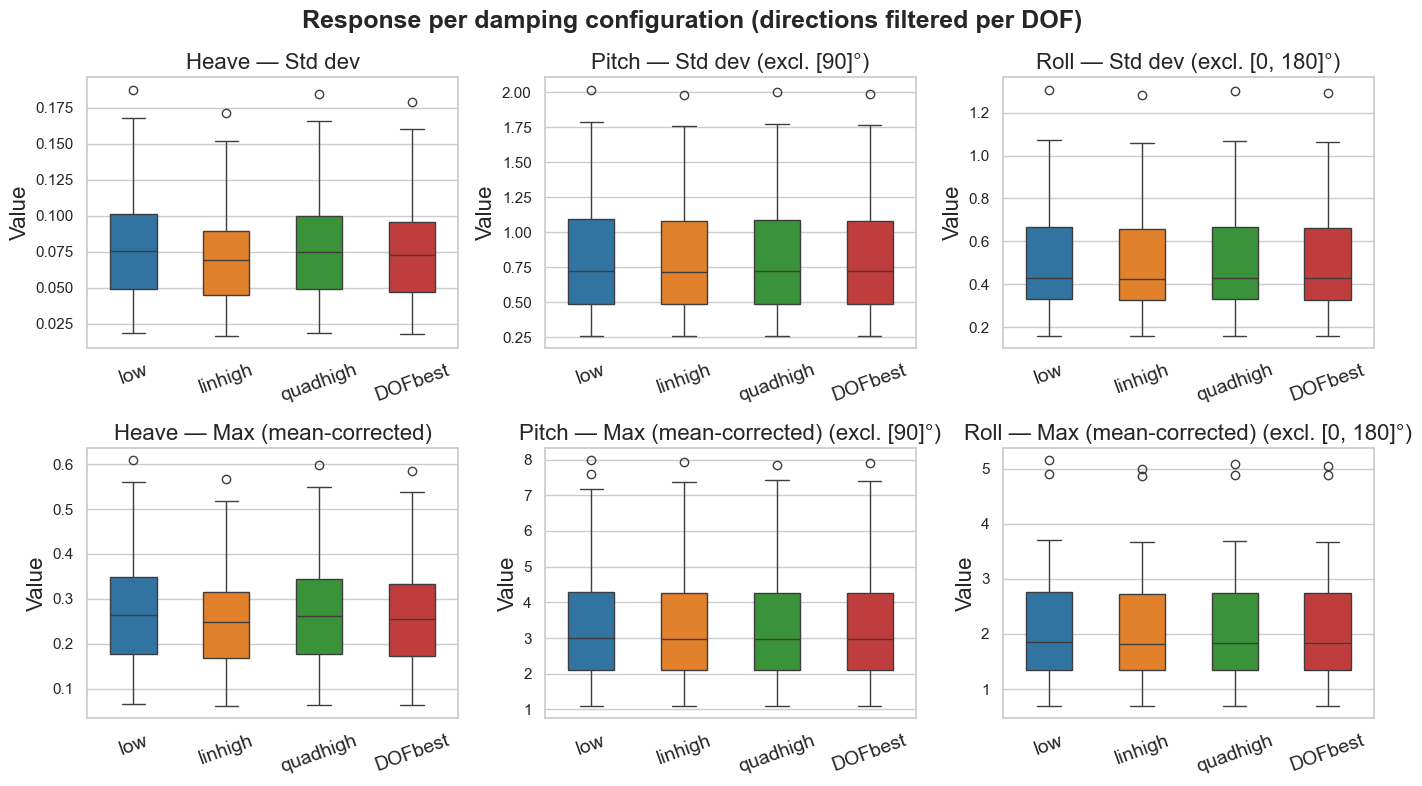

In [26]:
dofs  = ['heave', 'pitch', 'roll']
stats = ['std', 'max']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Response per damping configuration (directions filtered per DOF)',
             fontsize=TITLE_SIZE, fontweight='bold')

for r, stat in enumerate(stats):
    for c, dof in enumerate(dofs):
        ax   = axes[r, c]
        col  = f'{dof}_{stat}'
        mask = ~df['Direction'].isin(DIR_EXCLUDE[dof])
        sns.boxplot(
            data=df[mask], x='damp_config', y=col, order=CONFIGS,
            palette='tab10', ax=ax, width=0.5
        )
        excl = DIR_EXCLUDE[dof]
        excl_str = f' (excl. {excl}°)' if excl else ''
        ax.set_title(f'{DOF_LABELS[dof]} — {STAT_LABELS[stat]}{excl_str}', fontsize=LABEL_SIZE)
        ax.set_xlabel('', fontsize=LABEL_SIZE)
        ax.set_ylabel('Value', fontsize=LABEL_SIZE)
        ax.tick_params(axis='x', rotation=20, labelsize=TICK_SIZE)

plt.tight_layout()
plt.savefig(DIR_PLOTS / 'fig_boxplots_overview.png', dpi=150)
plt.show()

## 4 — Effect of Tp per damping config
Mean response as a function of wave period, split by Hs.

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1612889494.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


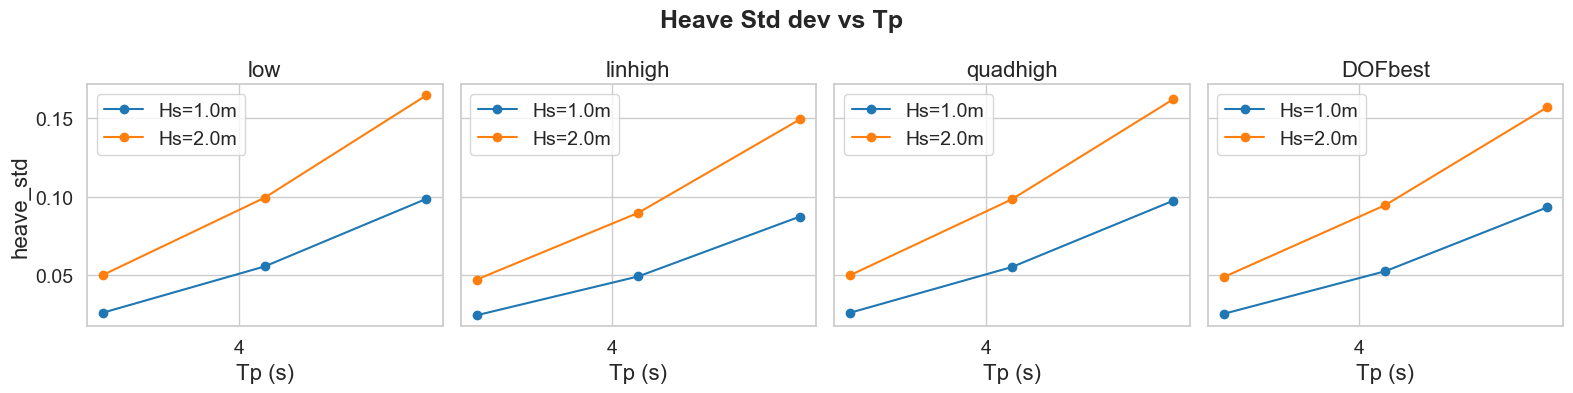

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1612889494.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


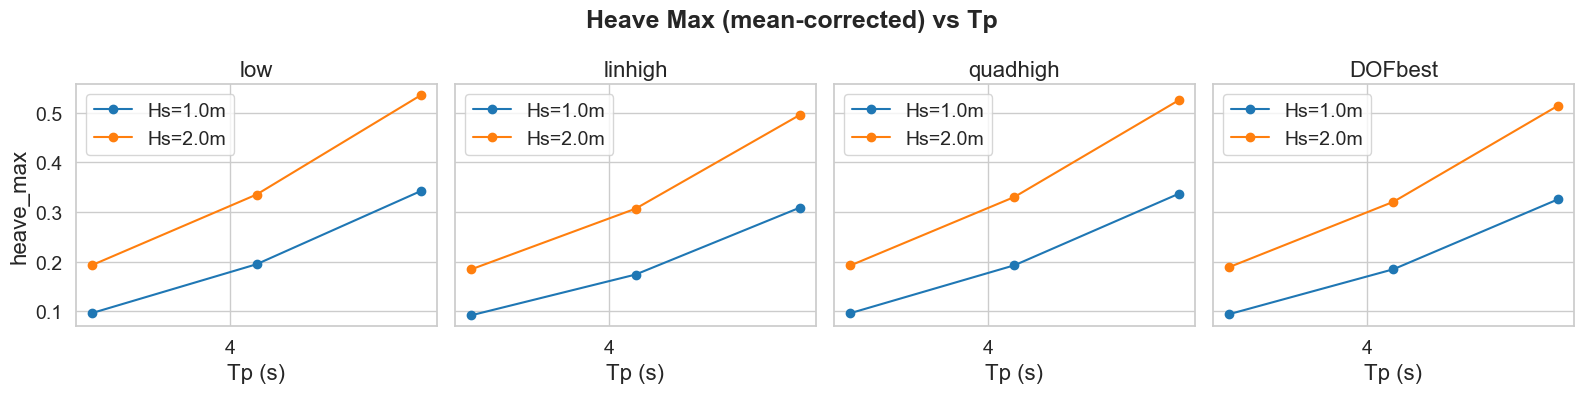

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1612889494.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


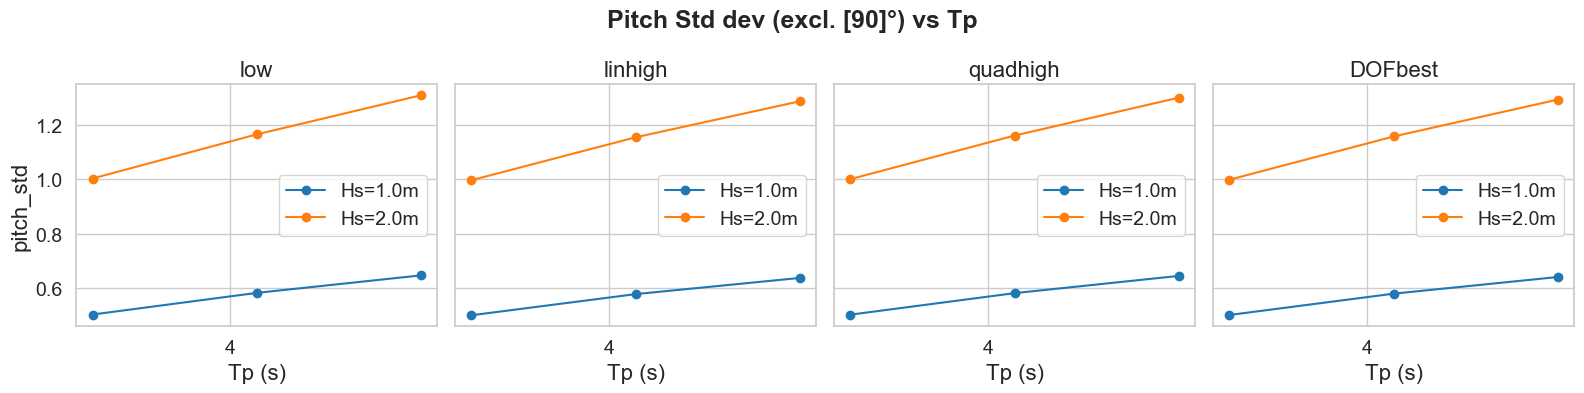

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1612889494.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


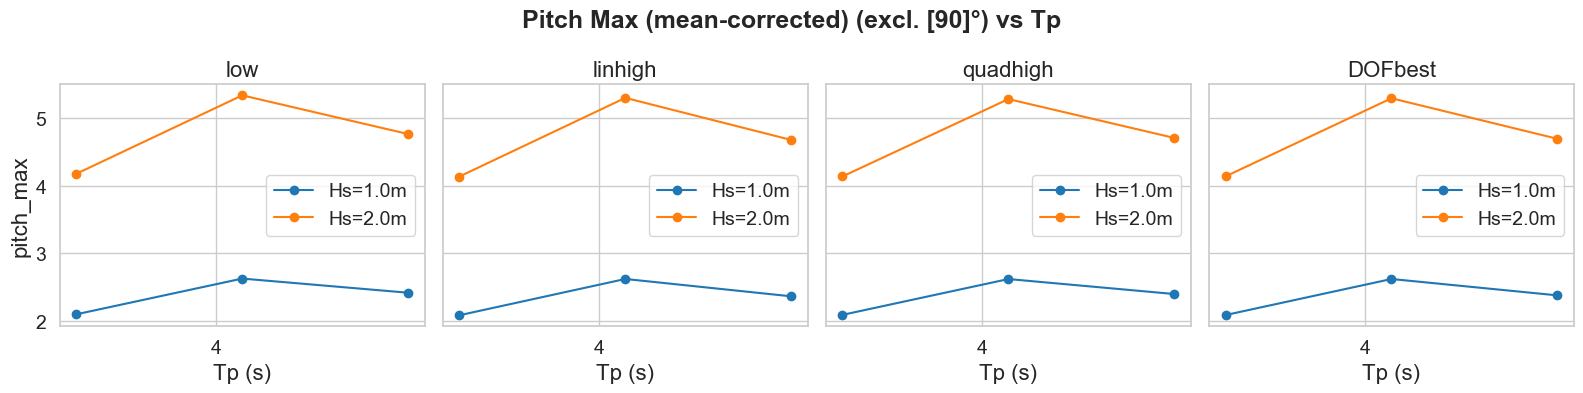

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1612889494.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


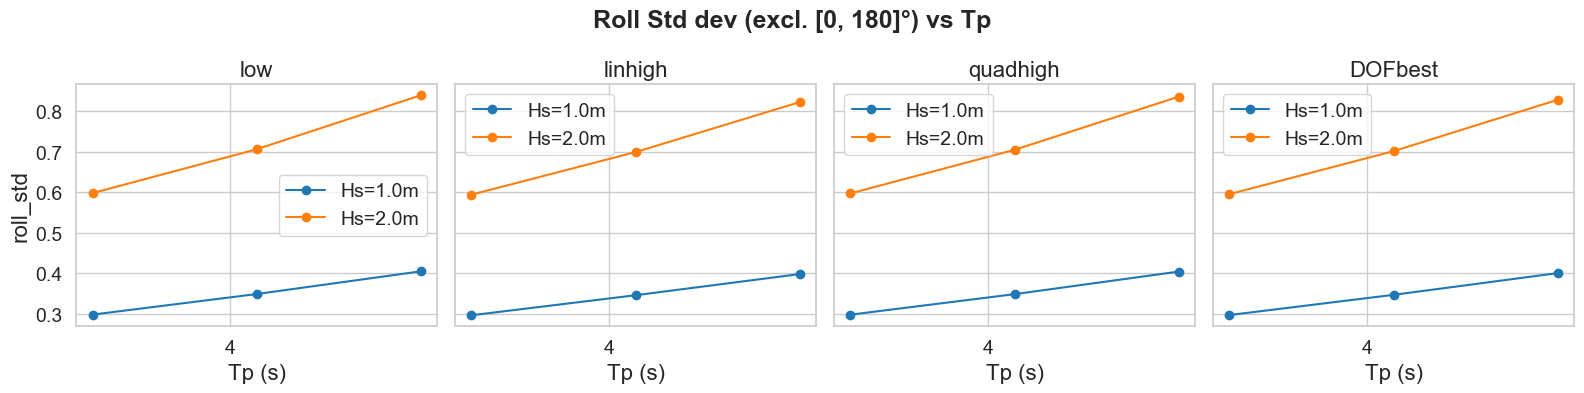

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1612889494.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


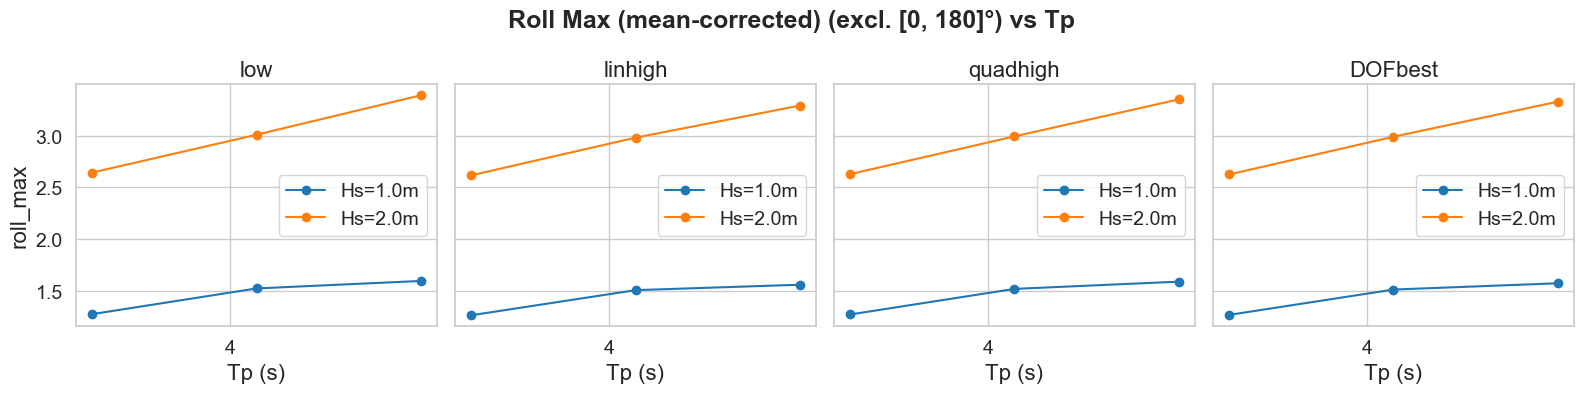

In [27]:
def plot_vs_Tp(dof, stat):
    col  = f'{dof}_{stat}'
    mask = ~df['Direction'].isin(DIR_EXCLUDE[dof])
    grp  = (df[mask]
            .groupby(['damp_config', 'Hs', 'Tp'])[col]
            .mean().reset_index())

    excl_str = f' (excl. {DIR_EXCLUDE[dof]}°)' if DIR_EXCLUDE[dof] else ''
    title    = f'{DOF_LABELS[dof]} {STAT_LABELS[stat]}{excl_str} vs Tp'

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    fig.suptitle(title, fontsize=TITLE_SIZE, fontweight='bold')

    for ax, cfg in zip(axes, CONFIGS):
        sub = grp[grp['damp_config'] == cfg]
        for hs, grp2 in sub.groupby('Hs'):
            ax.plot(grp2['Tp'], grp2[col], marker='o', label=f'Hs={hs}m')
        ax.set_title(cfg, fontsize=LABEL_SIZE)
        ax.set_xlabel('Tp (s)', fontsize=LABEL_SIZE)
        ax.set_ylabel(col if ax == axes[0] else '', fontsize=LABEL_SIZE)
        ax.legend(fontsize=TICK_SIZE)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
        ax.tick_params(axis='both', labelsize=TICK_SIZE)

    plt.tight_layout()
    plt.savefig(DIR_PLOTS / f'fig_Tp_{col}.png', dpi=150)
    plt.show()

for dof in ['heave', 'pitch', 'roll']:
    for stat in ['std', 'max']:
        plot_vs_Tp(dof, stat)

## 5 — Directional dependency per damping config

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\2788431742.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp      = df.groupby(['damp_config', 'Direction'])[col].mean().reset_index()


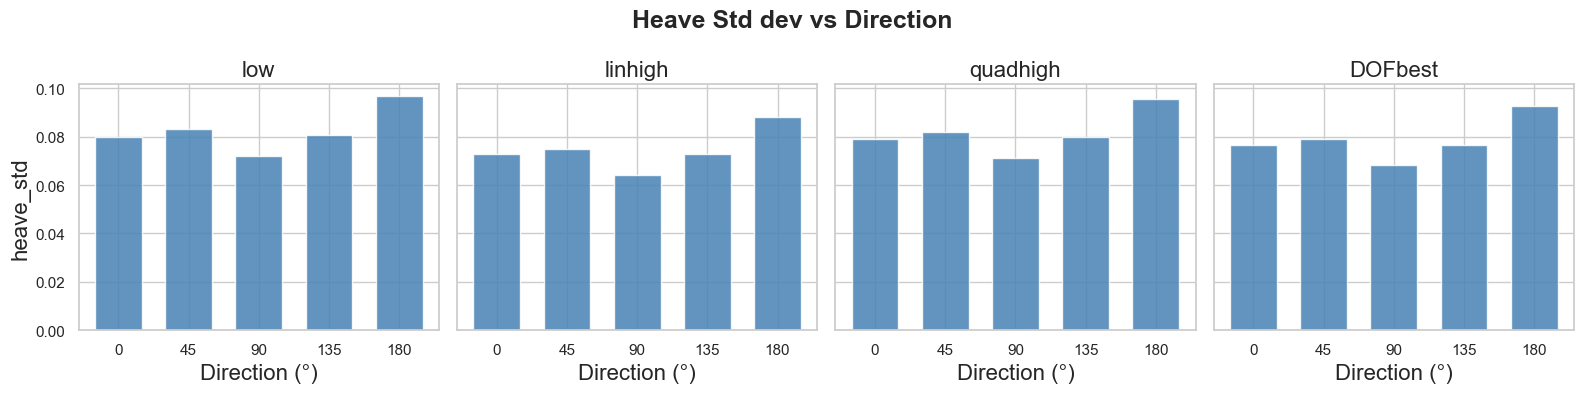

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\2788431742.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp      = df.groupby(['damp_config', 'Direction'])[col].mean().reset_index()


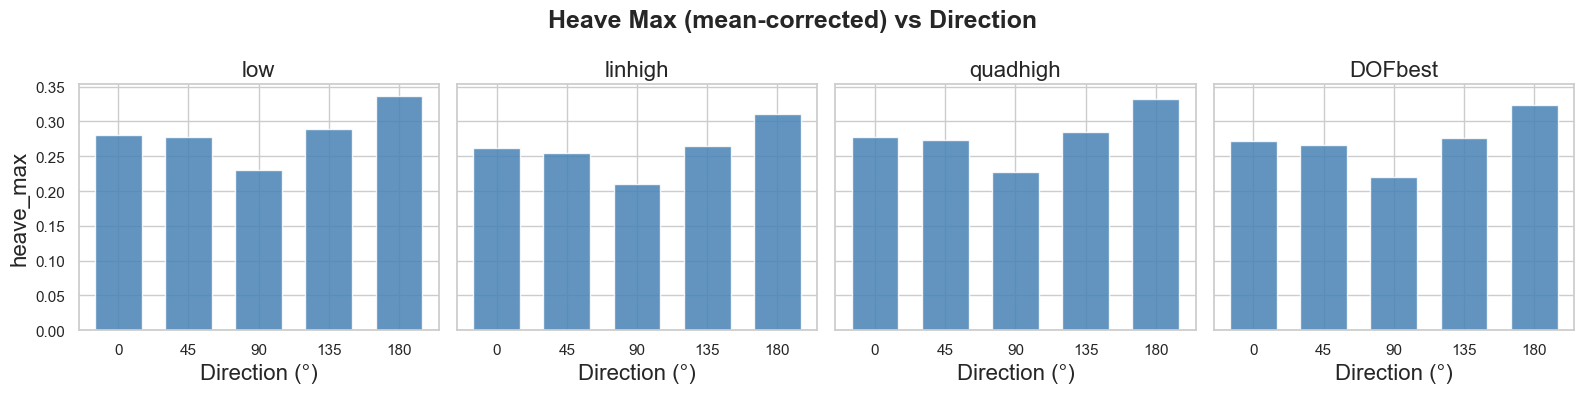

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\2788431742.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp      = df.groupby(['damp_config', 'Direction'])[col].mean().reset_index()


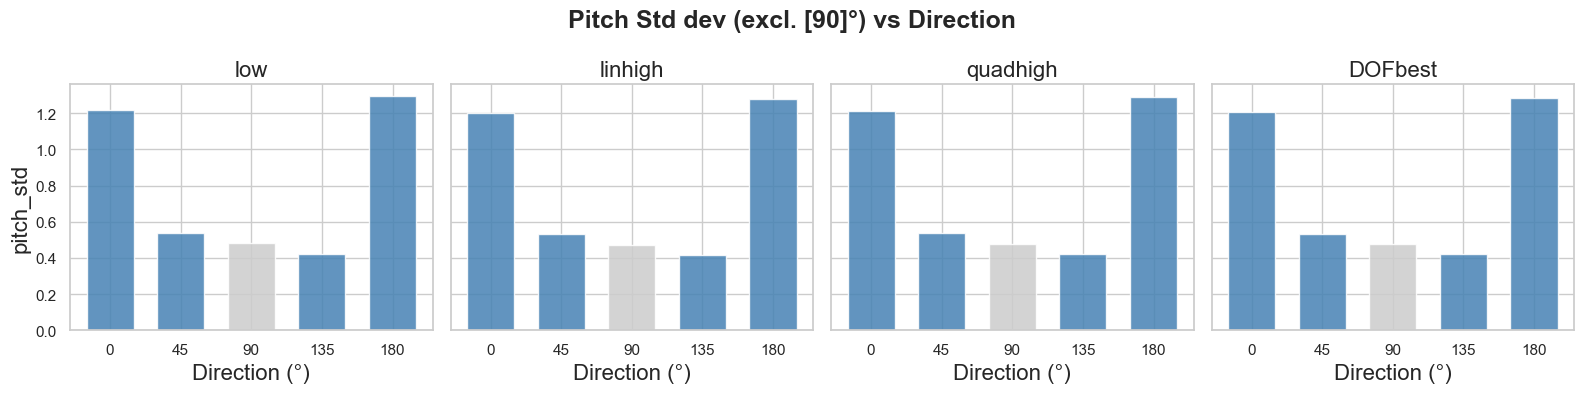

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\2788431742.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp      = df.groupby(['damp_config', 'Direction'])[col].mean().reset_index()


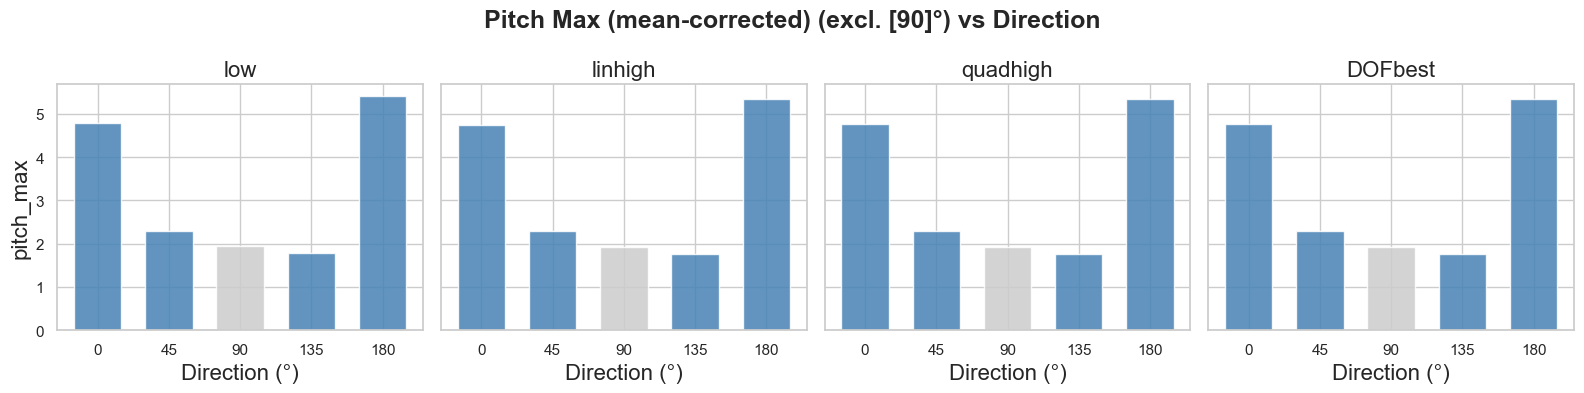

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\2788431742.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp      = df.groupby(['damp_config', 'Direction'])[col].mean().reset_index()


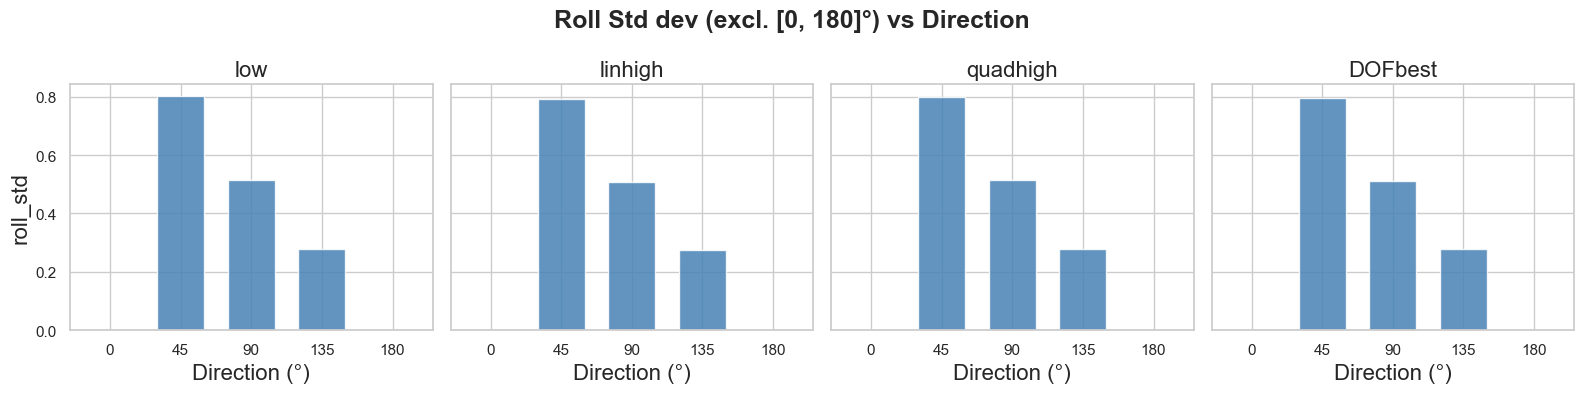

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\2788431742.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp      = df.groupby(['damp_config', 'Direction'])[col].mean().reset_index()


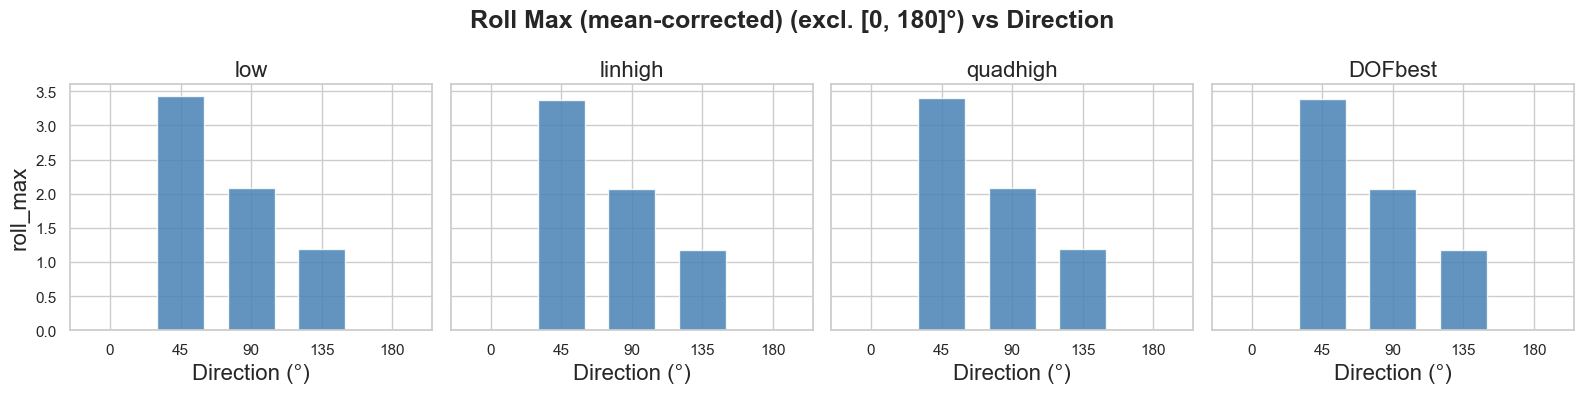

In [28]:
def plot_vs_dir(dof, stat):
    """Bar plot per direction; excluded directions shown in grey."""
    col      = f'{dof}_{stat}'
    excluded = DIR_EXCLUDE[dof]
    grp      = df.groupby(['damp_config', 'Direction'])[col].mean().reset_index()
    all_dirs = sorted(df['Direction'].unique())

    excl_str = f' (excl. {excluded}°)' if excluded else ''
    title    = f'{DOF_LABELS[dof]} {STAT_LABELS[stat]}{excl_str} vs Direction'

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    fig.suptitle(title, fontsize=TITLE_SIZE, fontweight='bold')

    for ax, cfg in zip(axes, CONFIGS):
        sub    = grp[grp['damp_config'] == cfg]
        colors = ['#cccccc' if d in excluded else 'steelblue' for d in sub['Direction']]
        ax.bar(sub['Direction'], sub[col], width=30, color=colors, alpha=0.85)
        ax.set_title(cfg, fontsize=LABEL_SIZE)
        ax.set_xlabel('Direction (°)', fontsize=LABEL_SIZE)
        ax.set_ylabel(col if ax == axes[0] else '', fontsize=LABEL_SIZE)
        ax.set_xticks(all_dirs)

    plt.tight_layout()
    plt.savefig(DIR_PLOTS / f'fig_dir_{col}.png', dpi=150)
    plt.show()

for dof in ['heave', 'pitch', 'roll']:
    for stat in ['std', 'max']:
        plot_vs_dir(dof, stat)

## 6 — Heatmap: Hs × Tp per damping config
Direction filter applied per DOF before aggregation.

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1724485021.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


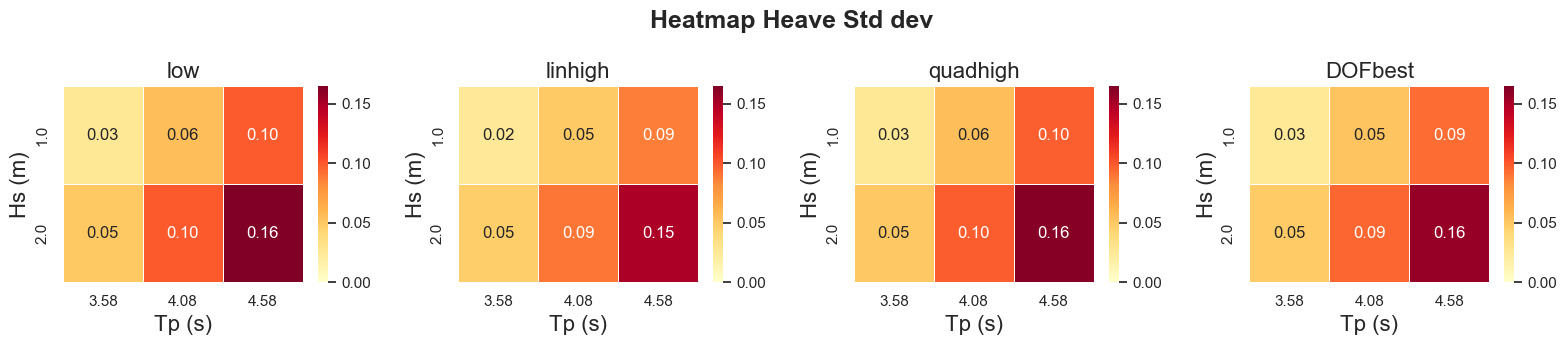

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1724485021.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


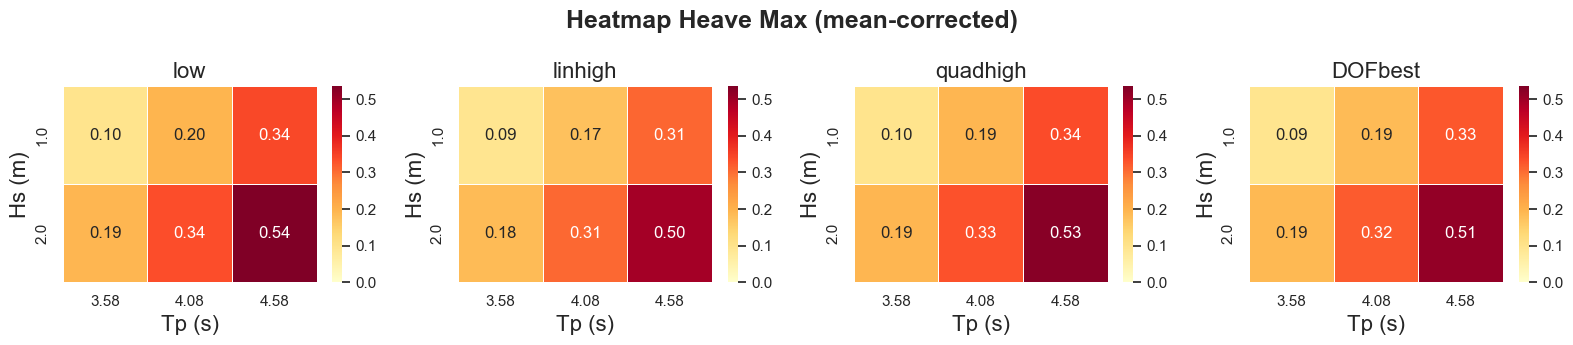

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1724485021.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


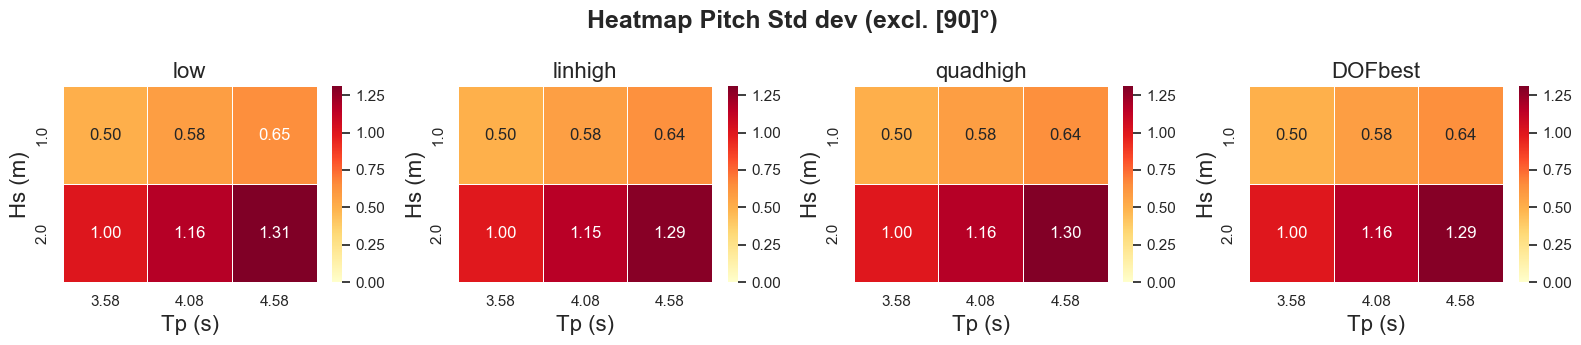

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1724485021.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


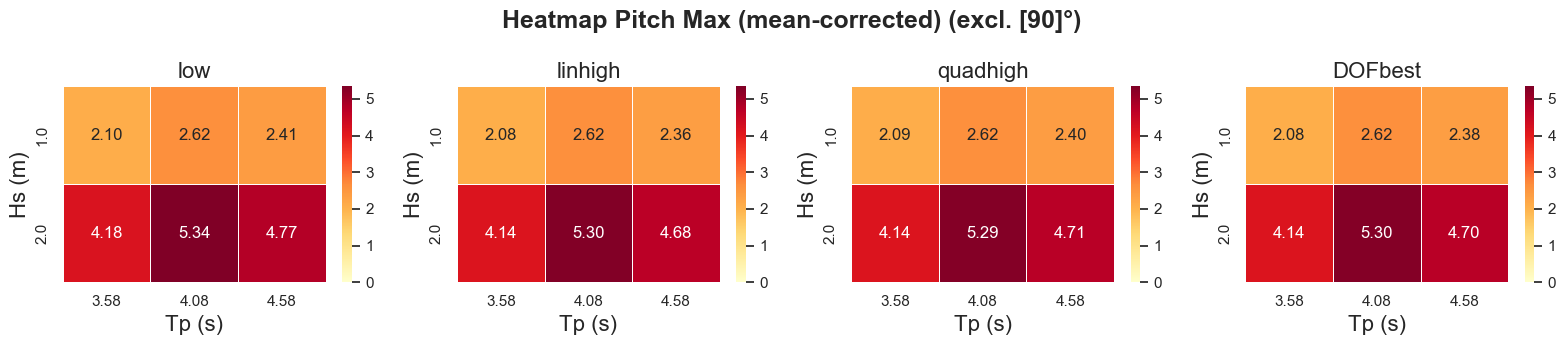

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1724485021.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


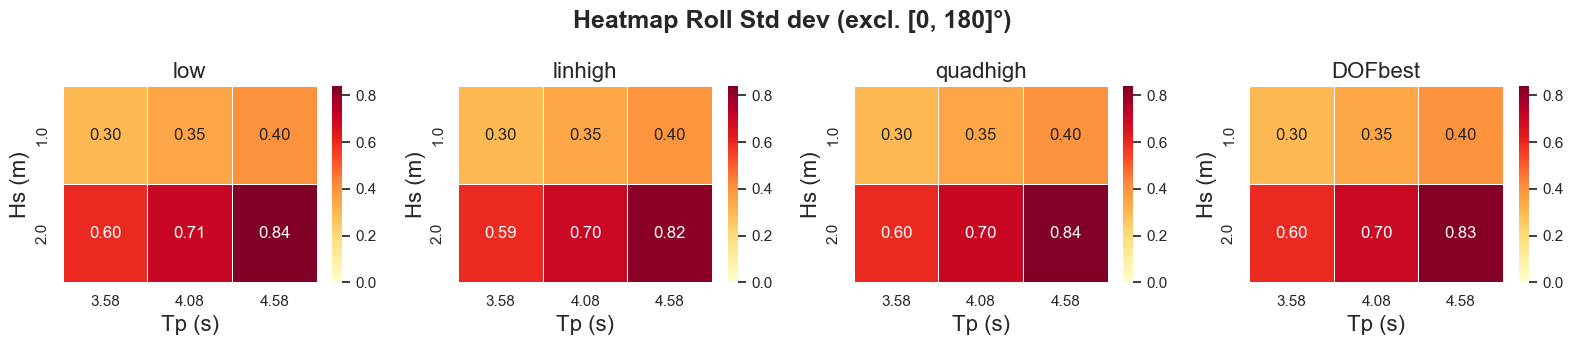

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1724485021.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['damp_config', 'Hs', 'Tp'])[col]


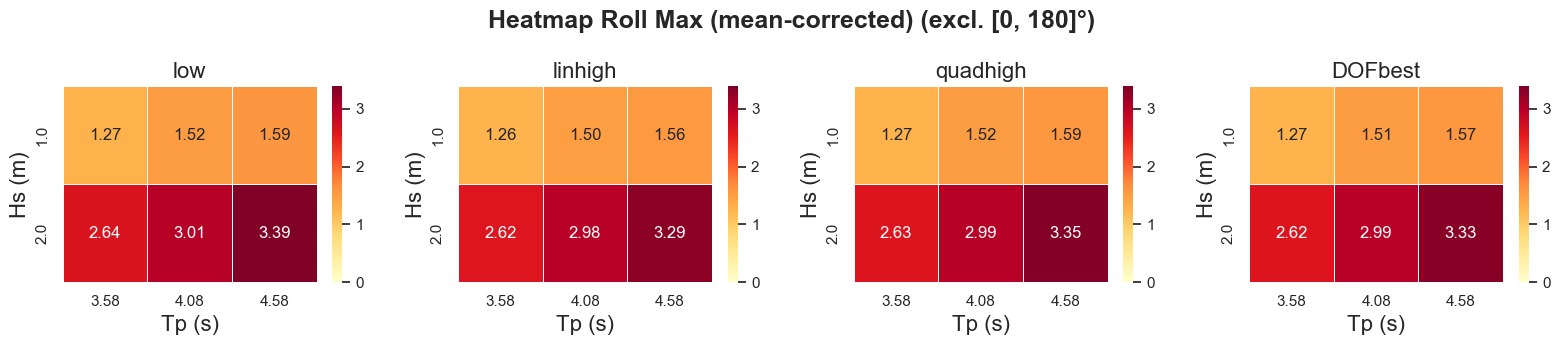

In [29]:
def plot_heatmap(dof, stat):
    col  = f'{dof}_{stat}'
    mask = ~df['Direction'].isin(DIR_EXCLUDE[dof])
    grp  = (df[mask]
            .groupby(['damp_config', 'Hs', 'Tp'])[col]
            .mean().reset_index())
    vmax = grp[col].max()

    excl_str = f' (excl. {DIR_EXCLUDE[dof]}°)' if DIR_EXCLUDE[dof] else ''
    title    = f'Heatmap {DOF_LABELS[dof]} {STAT_LABELS[stat]}{excl_str}'

    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
    fig.suptitle(title, fontsize=TITLE_SIZE, fontweight='bold')

    for ax, cfg in zip(axes, CONFIGS):
        pivot = (grp[grp['damp_config'] == cfg]
                 .pivot(index='Hs', columns='Tp', values=col))
        sns.heatmap(
            pivot, ax=ax, cmap='YlOrRd', vmin=0, vmax=vmax,
            annot=True, fmt='.2f', linewidths=0.5
        )
        ax.set_title(cfg, fontsize=LABEL_SIZE)
        ax.set_xlabel('Tp (s)', fontsize=LABEL_SIZE)
        ax.set_ylabel('Hs (m)', fontsize=LABEL_SIZE)

    plt.tight_layout()
    plt.savefig(DIR_PLOTS / f'fig_heatmap_{col}.png', dpi=150)
    plt.show()

for dof in ['heave', 'pitch', 'roll']:
    for stat in ['std', 'max']:
        plot_heatmap(dof, stat)

## 7 — Comparison vs. baseline (`low`)
Percentage change relative to the `low` damping config.
Direction filter applied per DOF before aggregation.

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\932058364.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df[mask].groupby('damp_config')[col].mean()


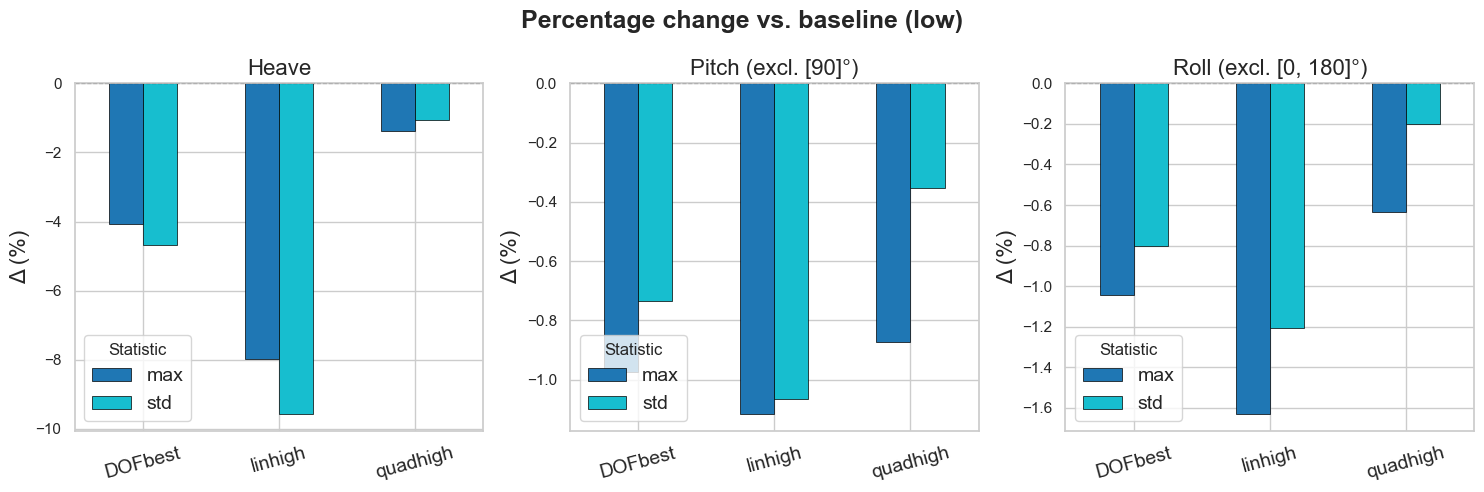

In [30]:
# Bereken gemiddelde per config, elk DOF met eigen richting-filter
records = []
for dof in ['heave', 'pitch', 'roll']:
    mask = ~df['Direction'].isin(DIR_EXCLUDE[dof])
    for stat in ['std', 'max']:
        col   = f'{dof}_{stat}'
        means = df[mask].groupby('damp_config')[col].mean()
        for cfg in CONFIGS:
            records.append({'dof': dof, 'stat': stat, 'config': cfg, 'mean': means[cfg]})

df_summary = pd.DataFrame(records)
baseline_map = df_summary[df_summary['config'] == 'low'].set_index(['dof', 'stat'])['mean']
df_summary['pct_change'] = df_summary.apply(
    lambda row: (row['mean'] - baseline_map[(row['dof'], row['stat'])]) /
                 baseline_map[(row['dof'], row['stat'])] * 100,
    axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Percentage change vs. baseline (low)', fontsize=TITLE_SIZE, fontweight='bold')

for ax, dof in zip(axes, ['heave', 'pitch', 'roll']):
    sub   = df_summary[(df_summary['dof'] == dof) & (df_summary['config'] != 'low')]
    pivot = sub.pivot(index='config', columns='stat', values='pct_change')
    pivot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='k', linewidth=0.5)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    excl     = DIR_EXCLUDE[dof]
    excl_str = f' (excl. {excl}°)' if excl else ''
    ax.set_title(f'{DOF_LABELS[dof]}{excl_str}', fontsize=LABEL_SIZE)
    ax.set_xlabel('', fontsize=LABEL_SIZE)
    ax.set_ylabel('Δ (%)', fontsize=LABEL_SIZE)
    ax.legend(title='Statistic', fontsize=TICK_SIZE)
    ax.tick_params(axis='x', rotation=15, labelsize=TICK_SIZE)

plt.tight_layout()
plt.savefig(DIR_PLOTS / 'fig_pct_change_vs_low.png', dpi=150)
plt.show()

## 8 — Summary table

In [31]:
rows = []
for dof in ['heave', 'pitch', 'roll']:
    mask = ~df['Direction'].isin(DIR_EXCLUDE[dof])
    for stat in ['std', 'max']:
        col = f'{dof}_{stat}'
        agg = df[mask].groupby('damp_config')[col].agg(['mean', 'max']).round(3)
        agg.columns = [f'{col}_mean', f'{col}_max']
        rows.append(agg)

summary_full = pd.concat(rows, axis=1)
print(summary_full.to_string())

summary_full.to_csv(DIR_RESULTS / 'summary_per_config.csv')
print(f'\n✅ Summary saved to {DIR_RESULTS}/summary_per_config.csv')

             heave_std_mean  heave_std_max  heave_max_mean  heave_max_max  pitch_std_mean  pitch_std_max  pitch_max_mean  pitch_max_max  roll_std_mean  roll_std_max  roll_max_mean  roll_max_max
damp_config                                                                                                                                                                                      
low                   0.083          0.188           0.283          0.609           0.868          2.018           3.571          7.982          0.532         1.307          2.238         5.152
linhigh               0.075          0.171           0.260          0.566           0.858          1.979           3.531          7.925          0.526         1.281          2.202         4.994
quadhigh              0.082          0.185           0.279          0.597           0.864          1.998           3.539          7.854          0.531         1.300          2.224         5.077
DOFbest               0.079   

C:\Users\verav\AppData\Local\Temp\ipykernel_13508\1779980555.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df[mask].groupby('damp_config')[col].agg(['mean', 'max']).round(3)
